In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle, Circle
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
from scipy.optimize import minimize

import poppy
import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

import warnings
warnings.filterwarnings("ignore")

from aefc_vortex.math_module import xp, xcipy, ensure_np_array
from aefc_vortex import utils
from aefc_vortex.imshows import imshow1, imshow2, imshow3
from aefc_vortex import dm
from aefc_vortex import props
from aefc_vortex import aefc_2dm as aefc
import aefc_vortex.fresnel_2dm_96 as fresnel
import aefc_vortex.fraunhofer_2dm_96 as fraunhofer

Nwaves = 15
wavelength_c = 650e-9
bw = 0.10
waves = np.linspace(wavelength_c * (1-bw/2), wavelength_c * (1+bw/2), Nwaves )
bandpasses = waves.reshape(3,5)
print(bandpasses)

Nwaves_per_bp = bandpasses.shape[1]
control_waves = bandpasses[:, Nwaves_per_bp//2]
print(control_waves)

# dm1_flat = xp.rot90(xp.rot90( utils.load_fits('data/dm1_flat_command_96.fits') ))
# M = fraunhofer.MODEL()
# dm1_flat += 1e-9*xp.random.randn(M.Nact,M.Nact) * M.dm_mask

[[6.17500000e-07 6.22142857e-07 6.26785714e-07 6.31428571e-07
  6.36071429e-07]
 [6.40714286e-07 6.45357143e-07 6.50000000e-07 6.54642857e-07
  6.59285714e-07]
 [6.63928571e-07 6.68571429e-07 6.73214286e-07 6.77857143e-07
  6.82500000e-07]]
[6.26785714e-07 6.50000000e-07 6.73214286e-07]


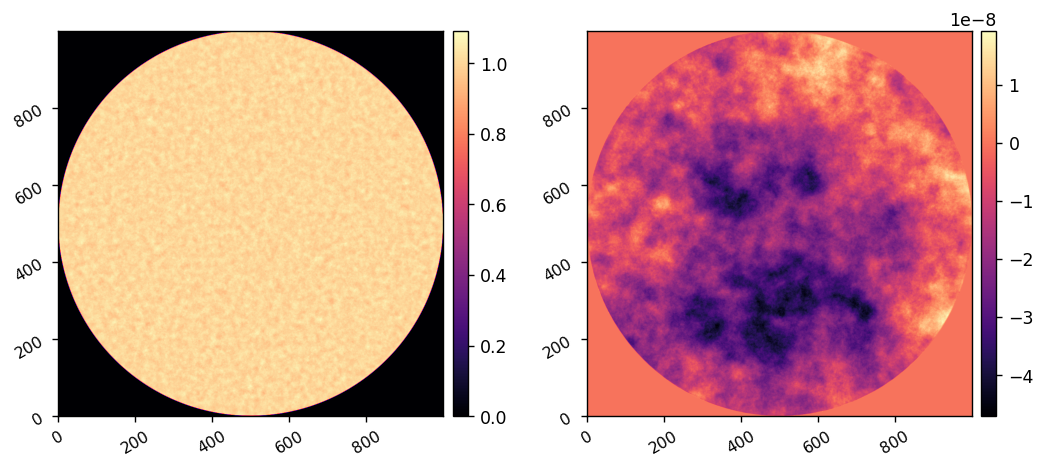

In [3]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True

AMP, OPD = I.calc_pupil()
imshow2(AMP, OPD)

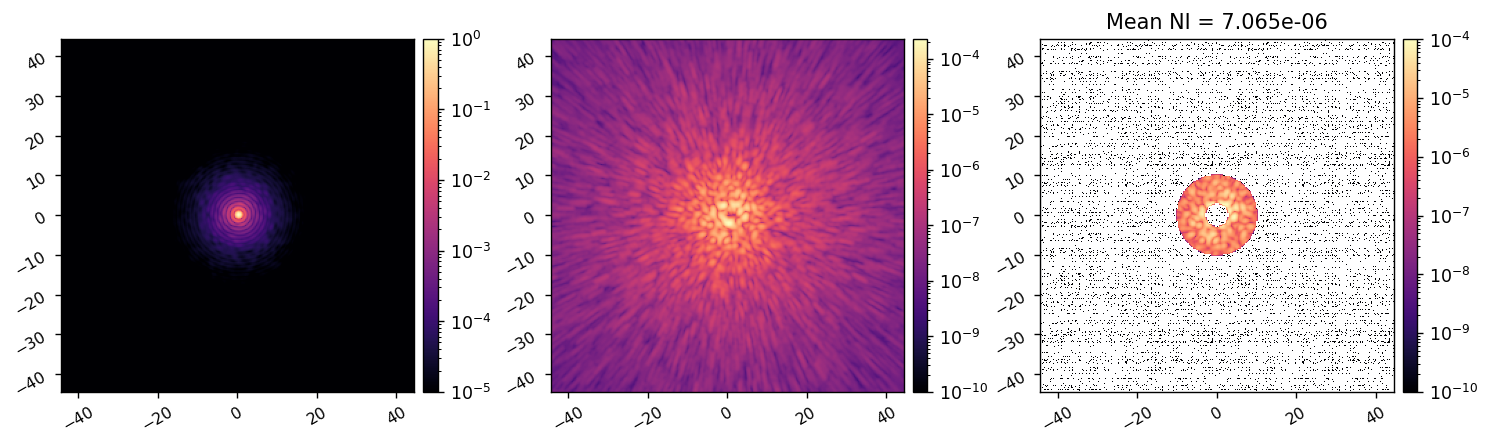

In [5]:
reload(fresnel)
I = fresnel.CORO()
I.use_opds = True
I.bandpasses = bandpasses

I.use_vortex = False
ref_psf = I.snap()
I.Imax_ref = xp.max(ref_psf)
ref_psf /= I.Imax_ref
I.use_vortex = True
ref_coro_im = I.snap()

reload(utils)
I.reset_dms()
iwa = 3
owa = 10
rot = 0
control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=None, rotation=rot)
# control_mask = utils.create_annular_focal_plane_mask(I.npsf, I.psf_pixelscale_lamDc, irad=iwa, orad=owa, edge=iwa, rotation=rot)
mean_ni0 = xp.mean(ref_coro_im[control_mask])

imshow3(
    ref_psf, ref_coro_im, ref_coro_im*control_mask,
    '', '', f'Mean NI = {mean_ni0:.3e}',
    pxscl=I.psf_pixelscale_lamDc, 
    lognorm=True, vmin1=1e-5, vmin2=1e-10, vmin3=1e-10,
)


In [14]:
mem_usage_from_fresnel_model = 3.794

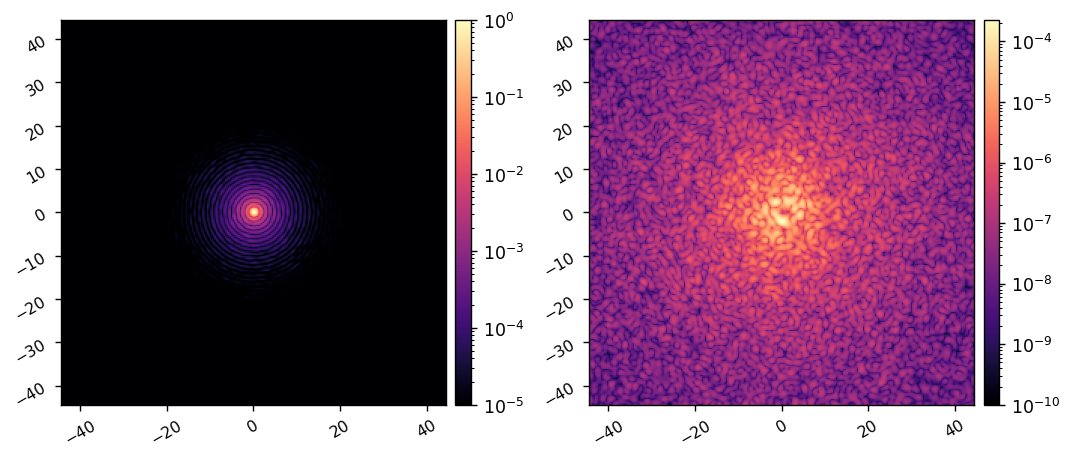

In [6]:
reload(fraunhofer)
M = fraunhofer.MODEL()
M.AMP = AMP
M.OPD = OPD

M.flip_dm = True
M.flip_lyot = True

acts = xp.zeros(M.Nacts)

model_psf = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=0) )**2
M.setattr('Imax_ref', xp.max(model_psf))
model_psf /= M.Imax_ref

model_coro_im = xp.abs( M.forward(acts, M.wavelength_c, use_vortex=1) )**2

imshow2(model_psf, model_coro_im,
        pxscl=M.psf_pixelscale_lamDc, lognorm=True, vmin1=1e-5, vmin2=1e-10)

In [8]:
mem_usage_with_forward_model = 6.610

In [7]:
I.reset_dms()
data = {
    # 'ref_im':ref_coro_im, 
    'images':[ref_coro_im],
    'efields':[],
    'dm1_commands':[],
    'del_dm1_commands':[],
    'dm2_commands':[],
    'del_dm2_commands':[],
    'reg_conds':[],
    'bfgs_tols':[],
    'pixelscale':I.psf_pixelscale_lamDc,
    'control_mask':control_mask, 
}

In [12]:
mem_usage_while_doing_aefc = 8.530

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  8.31944D+06


 This problem is unconstrained.



At iterate    1    f=  9.94028D-01    |proj g|=  7.04883D+06

At iterate    2    f=  9.70305D-01    |proj g|=  1.80205D+06

At iterate    3    f=  9.66551D-01    |proj g|=  1.80615D+06

At iterate    4    f=  9.55474D-01    |proj g|=  1.70238D+06

At iterate    5    f=  9.51032D-01    |proj g|=  2.86797D+06

At iterate    6    f=  9.45008D-01    |proj g|=  1.46503D+06

At iterate    7    f=  9.41412D-01    |proj g|=  9.89161D+05

At iterate    8    f=  9.37874D-01    |proj g|=  1.15076D+06

At iterate    9    f=  9.33798D-01    |proj g|=  2.24311D+06

At iterate   10    f=  9.28847D-01    |proj g|=  1.17897D+06

At iterate   11    f=  9.24164D-01    |proj g|=  1.29421D+06

At iterate   12    f=  9.19740D-01    |proj g|=  1.69706D+06

At iterate   13    f=  9.15371D-01    |proj g|=  1.45653D+06

At iterate   14    f=  9.10800D-01    |proj g|=  1.34468D+06

At iterate   15    f=  9.06831D-01    |proj g|=  1.26818D+06

At iterate   16    f=  9.04220D-01    |proj g|=  1.29577D+06

At iter

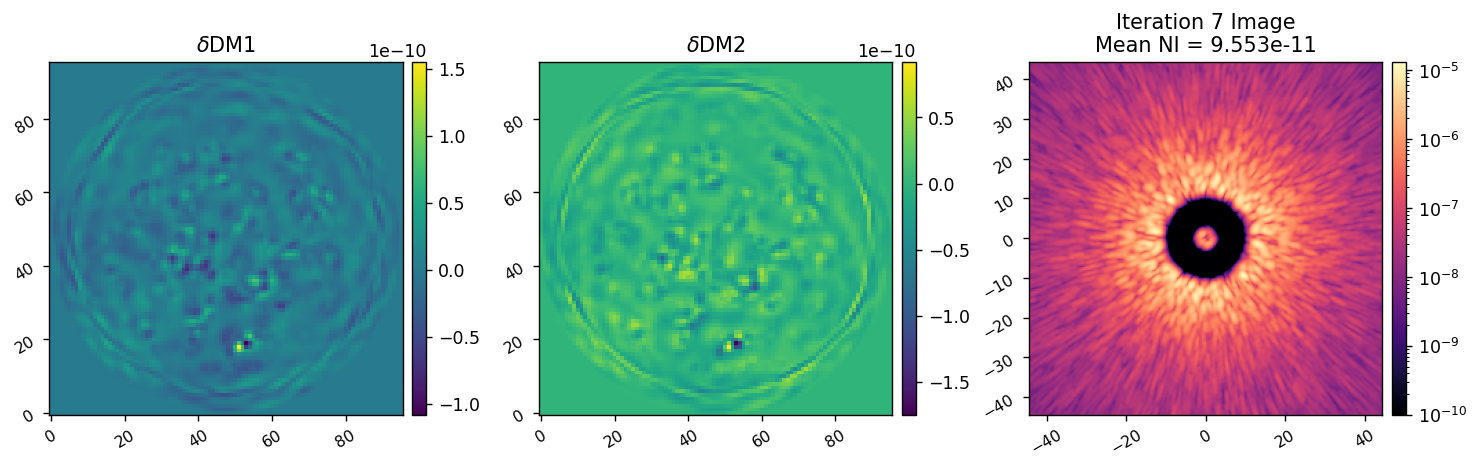

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  2.58045D+06


 This problem is unconstrained.



At iterate    1    f=  9.99136D-01    |proj g|=  2.05232D+06

At iterate    2    f=  9.94948D-01    |proj g|=  9.81397D+05

At iterate    3    f=  9.93422D-01    |proj g|=  1.09254D+06

At iterate    4    f=  9.89429D-01    |proj g|=  1.36869D+06

At iterate    5    f=  9.88570D-01    |proj g|=  2.43206D+06

At iterate    6    f=  9.84619D-01    |proj g|=  8.38186D+05

At iterate    7    f=  9.82783D-01    |proj g|=  7.93007D+05

At iterate    8    f=  9.80784D-01    |proj g|=  8.81863D+05

At iterate    9    f=  9.78693D-01    |proj g|=  9.51965D+05

At iterate   10    f=  9.76878D-01    |proj g|=  9.93472D+05

At iterate   11    f=  9.74995D-01    |proj g|=  8.45406D+05

At iterate   12    f=  9.72931D-01    |proj g|=  7.87811D+05

At iterate   13    f=  9.71701D-01    |proj g|=  1.55833D+06

At iterate   14    f=  9.69750D-01    |proj g|=  8.93188D+05

At iterate   15    f=  9.67370D-01    |proj g|=  9.40462D+05

At iterate   16    f=  9.66378D-01    |proj g|=  1.56401D+06

At iter

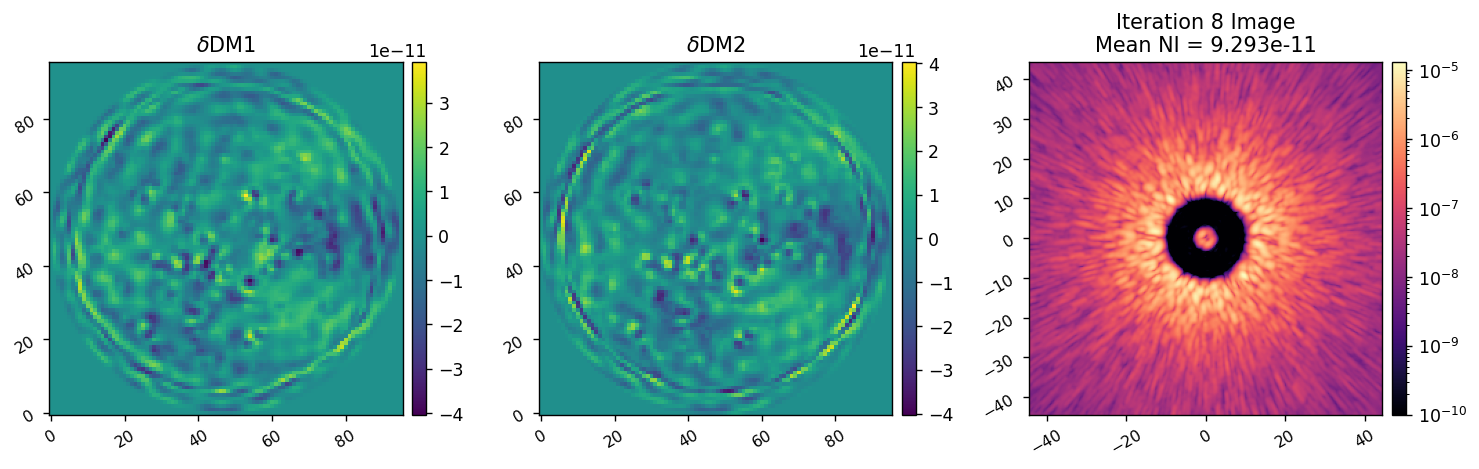

Computing E-field with model ...
Computing EFC command with L-BFGS
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =        14736     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00000D+00    |proj g|=  1.36931D+06


 This problem is unconstrained.



At iterate    1    f=  9.99362D-01    |proj g|=  1.27070D+06

At iterate    2    f=  9.96359D-01    |proj g|=  8.85744D+05

At iterate    3    f=  9.95368D-01    |proj g|=  8.30753D+05

At iterate    4    f=  9.92846D-01    |proj g|=  8.64967D+05

At iterate    5    f=  9.92162D-01    |proj g|=  2.05595D+06

At iterate    6    f=  9.89476D-01    |proj g|=  1.27582D+06

At iterate    7    f=  9.87381D-01    |proj g|=  8.97251D+05

At iterate    8    f=  9.84790D-01    |proj g|=  1.36985D+06

At iterate    9    f=  9.81476D-01    |proj g|=  1.28273D+06

At iterate   10    f=  9.81332D-01    |proj g|=  2.31657D+06

At iterate   11    f=  9.77889D-01    |proj g|=  7.96163D+05

At iterate   12    f=  9.76543D-01    |proj g|=  7.20850D+05

At iterate   13    f=  9.74884D-01    |proj g|=  8.54265D+05

At iterate   14    f=  9.72796D-01    |proj g|=  1.23789D+06

At iterate   15    f=  9.72407D-01    |proj g|=  1.05652D+06

At iterate   16    f=  9.70946D-01    |proj g|=  9.38223D+05

At iter

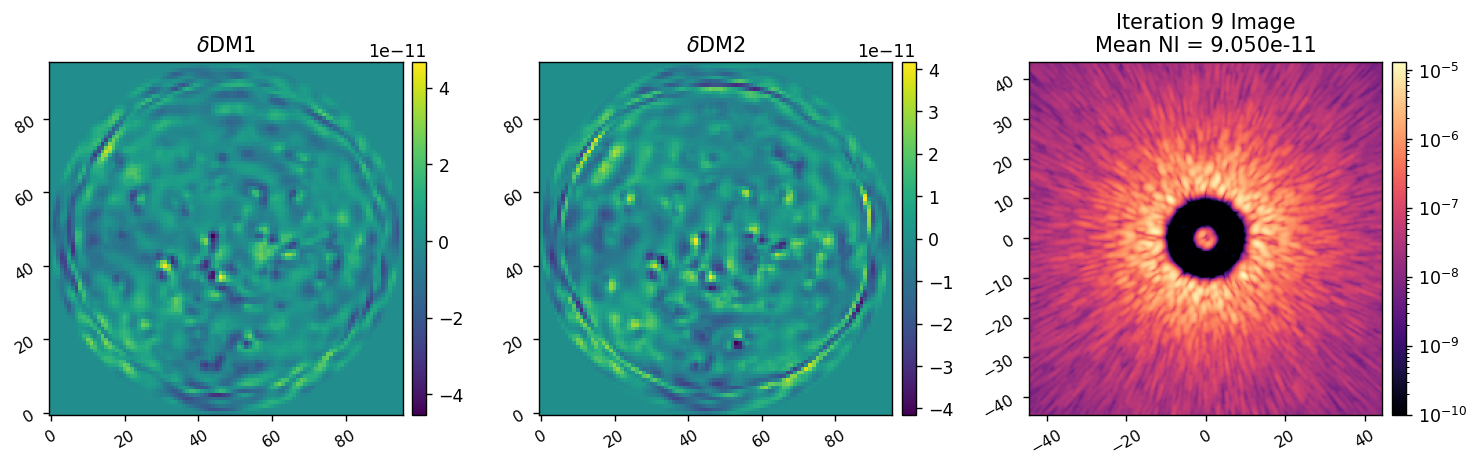

In [10]:
reload(fraunhofer)
reload(aefc)

bfgs_tol = 1e-2
bfgs_tol = 1e-3
bfgs_tol = 1e-4
# bfgs_tol = 1e-5
# bfgs_tol = 1e-10

bfgs_opts = {
    'disp':True,
    'maxls':10, 
    'maxiter':50,
    # 'ftol':1e-6,
    # 'gtol':1e-6,
}

data = aefc.run_bb(
    I, 
    M, 
    fraunhofer.val_and_grad_bb, 
    control_mask, 
    data,
    # Nitr=3, reg_cond=1e-1,
    # Nitr=3, reg_cond=1e-2,
    Nitr=3, reg_cond=1e-3,
    # Nitr=3, reg_cond=1e-4,
    # Nitr=3, reg_cond=1e-5,
    # Nitr=3, reg_cond=1e-6,
    # Nitr=3, reg_cond=1e-7,
    # Nitr=3, reg_cond=1e-8,
    # Nitr=3, reg_cond=1e-12,
    # weights=np.array([20,1,20]), 
    bfgs_tol=bfgs_tol,
    bfgs_opts=bfgs_opts,
    gain=1,
)



In [17]:
print(mem_usage_from_fresnel_model, mem_usage_with_forward_model, mem_usage_while_doing_aefc)

3.794 6.61 8.53


In [18]:
aefc_mem_usage = mem_usage_while_doing_aefc - mem_usage_with_forward_model
print(aefc_mem_usage)

aefc_mem_usage = mem_usage_while_doing_aefc - mem_usage_from_fresnel_model
print(aefc_mem_usage)

1.919999999999999
4.735999999999999


In [11]:
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
now = datetime.now().strftime('%Y%m%d%H%M%S')
utils.save_pickle(f'/npool/nvme/kianmilani/aefc-vortex-data/fresnel_96_aefc_3-10_run_{now}.pkl', data)

Saved data to:  /npool/nvme/kianmilani/aefc-vortex-data/fresnel_96_aefc_3-10_run_20250425101042.pkl


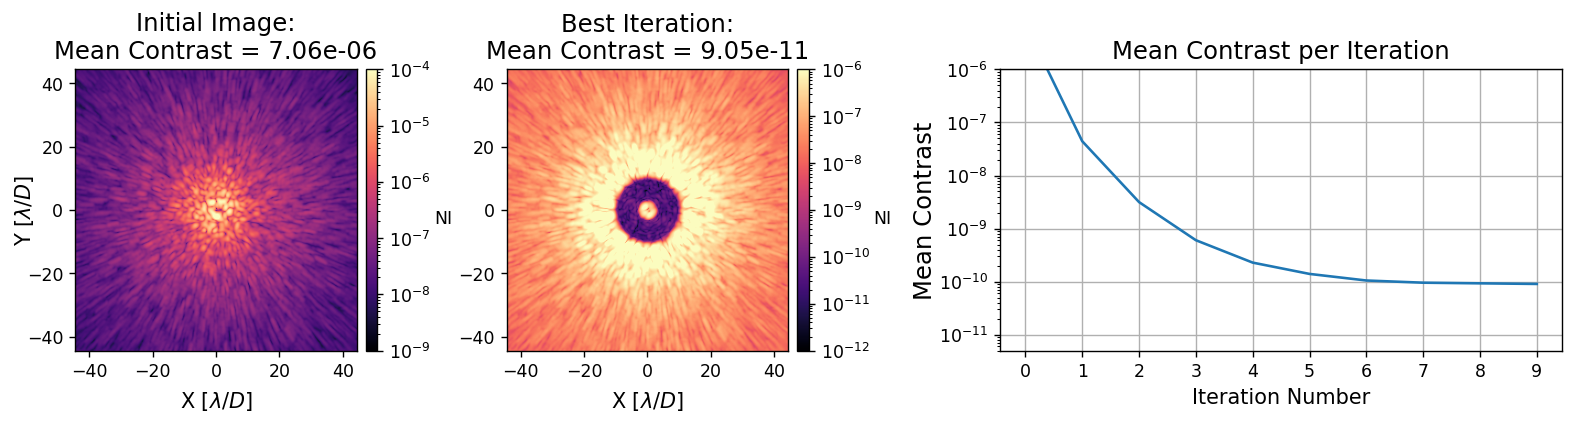

In [12]:
import aefc_vortex.imshows as imshows

imshows.plot_howfsc_data(
    data, 
    vmin=5e-12, 
    vmax=1e-6,
    im1vmin=1e-9, 
    im1vmax=1e-4,
    im2vmin=1e-12, 
    im2vmax=1e-6,    
    xticks=np.linspace(0,9,10),
)

In [17]:
xp.array(data['images']).shape

(10, 256, 256)

[1.75761068e-05 7.90588961e-08 5.38908977e-09 1.11975970e-09
 4.12918487e-10 1.91918224e-10 1.28756548e-10 1.09620179e-10
 1.01201792e-10 9.30274997e-11]


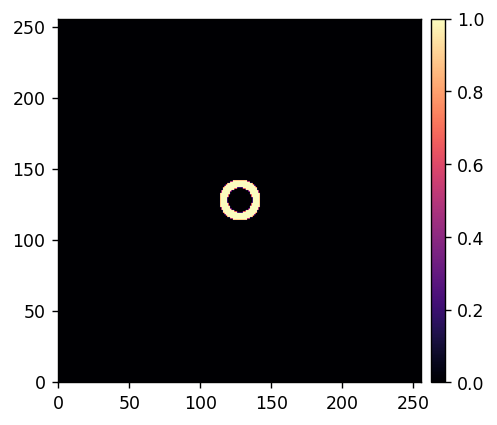

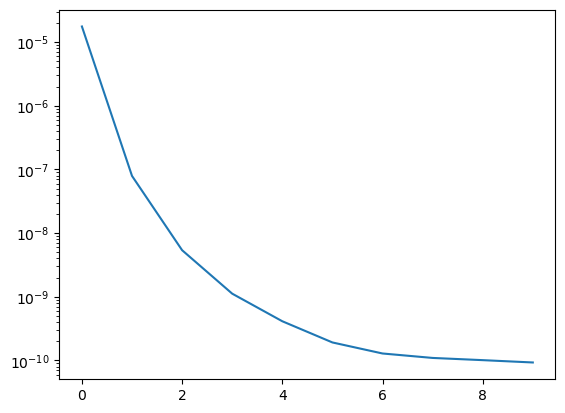

In [19]:
small_mask = utils.create_annular_focal_plane_mask(
    I.npsf, 
    I.psf_pixelscale_lamDc, 
    irad=iwa, 
    orad=5, 
    edge=None, 
    rotation=0,
)
small_nis = xp.mean(xp.array(data['images'])[:, small_mask], axis=1)
print(small_nis)

utils.imshow([small_mask])
import matplotlib.pyplot as plt

plt.semilogy(ensure_np_array(small_nis))